# Notebook 08a: Continual Learning CNN Training

This notebook trains the GaitCNN encoder in a class-incremental continual learning (CL) setting. Two methods are compared:

- **Std** (naive fine-tuning): the model is trained on each task in sequence with no mechanism to prevent forgetting. Previous task knowledge is overwritten as new tasks are learned.
- **CDML** (Code Division Modulation Layer, Milani WIFS 2024): each task k is assigned a binary code $s_k \in \{-1, +1\}^{2048}$. Before the FC classification head, the 2048-dim embedding is modulated element-wise by $s_k$. This separates tasks in the embedding space and reduces catastrophic forgetting.

The pipeline follows the same protocol as NB02 for single-task identification, extended to the CL setting.

```
Phase 1 (NB02):  GaitCNN trained on all 98 subjects at once        [single task]
Phase 1 (here):  GaitCNN trained on 4 tasks × 24 subjects each     [class-incremental CL]
```

The CL-trained backbone is frozen and passed to NB08b for authenticator training.

## Task setup

The 98 whuGAIT subjects are split as follows:

| Split | Subjects | Role |
|---|---|---|
| Tasks 0-3 | 4 × 24 = 96 members | CL training subjects |
| Leftover | 2 subjects | Treated as non-members in NB08c |
| Held-out | 20 subjects (Dataset #2) | Non-members for MIA evaluation |

To avoid task-size confounds in the MIA comparison, the training windows are subsampled to the minimum window count across all four tasks before training begins.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, '..')

import json, time, logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import ExponentialLR

from src.models.gait_cnn import GaitCNN
from src.models.cl_cnn   import CDMLGaitCNN
from src.data.dataset    import load_dataset, filter_subjects, normalize

# ── config ──
N_TASKS           = 4
SUBJECTS_PER_TASK = 24
N_CLASSES         = N_TASKS * SUBJECTS_PER_TASK   # 96
EPOCHS_PER_TASK   = 100
LR, LR_GAMMA      = 1e-3, 0.9
BATCH_SIZE        = 512
SEED_BASE         = 1000
DEVICE            = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_ROOT    = Path('../data')
ARTIFACT_DIR = Path('../artifacts/whuGAIT')
CKPT_DIR     = Path('../checkpoints/whuGAIT/cl8')
RESULT_DIR   = Path('../results/whuGAIT')
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

log = logging.getLogger('nb08a')
log.setLevel(logging.INFO)
log.handlers.clear()
log.addHandler(logging.StreamHandler())

log.info(f'Device: {DEVICE}  |  Tasks: {N_TASKS}  |  Subjects/task: {SUBJECTS_PER_TASK}')

Device: cpu  |  Tasks: 4  |  Subjects/task: 24


## 1. Data loading and task split

In [3]:
with open(ARTIFACT_DIR / 'subject_split.json') as f:
    split = json.load(f)

all_member_ids    = sorted(split['train_ids'])
all_nonmember_ids = sorted(split['held_out_ids'])

member_ids    = all_member_ids[:N_TASKS * SUBJECTS_PER_TASK]   # 96
leftover_ids  = all_member_ids[N_TASKS * SUBJECTS_PER_TASK:]   # 2
id_to_cls     = {sid: i for i, sid in enumerate(member_ids)}

tasks = [
    {'task_id': k,
     'subject_ids': member_ids[k*SUBJECTS_PER_TASK:(k+1)*SUBJECTS_PER_TASK]}
    for k in range(N_TASKS)
]

X_raw_tr, y_raw_tr = load_dataset(str(DATA_ROOT / 'Dataset #1'), 'train')
X_raw_te, y_raw_te = load_dataset(str(DATA_ROOT / 'Dataset #1'), 'test')
X_mem_tr, _        = filter_subjects(X_raw_tr, y_raw_tr, member_ids)
_, norm_stats       = normalize(X_mem_tr)
X_tr, _ = normalize(X_raw_tr, norm_stats)
X_te, _ = normalize(X_raw_te, norm_stats)

# equal windows per task: subsample training data to min task window count
task_window_counts = [np.isin(y_raw_tr, t['subject_ids']).sum() for t in tasks]
min_windows = min(task_window_counts)
log.info(f'Windows per task: {task_window_counts}  →  subsample to {min_windows}')

def make_loader_equal(X, y, sids, cls_map, n_max, seed=42, shuffle=True):
    mask = np.isin(y, sids)
    Xs, ys = X[mask], y[mask]
    ys = np.array([cls_map[s] for s in ys], dtype=np.int64)
    if len(Xs) > n_max:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(Xs), n_max, replace=False)
        Xs, ys = Xs[idx], ys[idx]
    return DataLoader(
        TensorDataset(torch.from_numpy(Xs).float(), torch.from_numpy(ys).long()),
        batch_size=BATCH_SIZE, shuffle=shuffle)

def make_loader(X, y, sids, cls_map):
    mask = np.isin(y, sids)
    Xs, ys = X[mask], y[mask]
    ys = np.array([cls_map[s] for s in ys], dtype=np.int64)
    return DataLoader(
        TensorDataset(torch.from_numpy(Xs).float(), torch.from_numpy(ys).long()),
        batch_size=BATCH_SIZE, shuffle=False)

task_train = [make_loader_equal(X_tr, y_raw_tr, t['subject_ids'], id_to_cls,
                                min_windows, seed=SEED_BASE+t['task_id']) for t in tasks]
task_eval  = [make_loader(X_te, y_raw_te, t['subject_ids'], id_to_cls) for t in tasks]

print(f'Members: {len(member_ids)}  |  Leftover (non-member): {len(leftover_ids)}')
print(f'Windows per task after subsampling: {min_windows} each')

Windows per task: [6257, 7116, 6386, 6661]  →  subsample to 6257


Members: 96  |  Leftover (non-member): 2
Windows per task after subsampling: 6257 each


## 2. CL training

Both methods use the same optimisation protocol from Milani WIFS 2024: Adam with initial learning rate 0.001 and exponential decay $\gamma = 0.9$ per epoch, for 100 epochs per task.

For CDML, before each task the model registers a new binary code generated from a seeded RNG and activates it for training. The FC head then sees $s_k \odot h$ instead of $h$ directly, so gradients for task $k$ are modulated differently from those of previous tasks.

Checkpoints from a previous run are loaded if available, skipping retraining.

In [4]:
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optim):
    model.train()
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optim.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optim.step()

def accuracy(model, loader, task_id=None):
    if task_id is not None and hasattr(model, 'set_task'):
        model.set_task(task_id)
    model.eval()
    corr = tot = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            corr += (model(x).argmax(1) == y).sum().item()
            tot  += len(y)
    return corr / tot

cl_records = {}

for use_cdml, label in [(False, 'std'), (True, 'cdml')]:
    # check if all checkpoints already exist
    if all((CKPT_DIR / f'{label}_task{k}.pt').exists() for k in range(N_TASKS)):
        log.info(f'[{label}] all checkpoints found, loading...')
        model = (CDMLGaitCNN(N_CLASSES) if use_cdml else GaitCNN(N_CLASSES)).to(DEVICE)
        if use_cdml:
            for k in range(N_TASKS):
                model.register_code(k, SEED_BASE + k)
        per_task_acc = []
        for tid in range(N_TASKS):
            model.load_state_dict(torch.load(CKPT_DIR / f'{label}_task{tid}.pt', map_location=DEVICE))
            if use_cdml:
                for k in range(N_TASKS):
                    model.register_code(k, SEED_BASE + k)
            pt = {i: accuracy(model, task_eval[i], task_id=i) for i in range(tid+1)}
            per_task_acc.append(pt)
        cl_records[label] = {'per_task_acc': per_task_acc}
        continue

    model = (CDMLGaitCNN(N_CLASSES) if use_cdml else GaitCNN(N_CLASSES)).to(DEVICE)
    per_task_acc = []
    t_total = time.time()

    for t in tasks:
        tid = t['task_id']
        if use_cdml:
            model.register_code(tid, SEED_BASE + tid)
            model.set_task(tid)

        optim = Adam(model.parameters(), lr=LR)
        sched = ExponentialLR(optim, LR_GAMMA)
        t0 = time.time()
        for ep in range(EPOCHS_PER_TASK):
            train_epoch(model, task_train[tid], optim)
            sched.step()

        pt = {i: accuracy(model, task_eval[i], task_id=i) for i in range(tid+1)}
        per_task_acc.append(pt)
        torch.save(model.state_dict(), CKPT_DIR / f'{label}_task{tid}.pt')
        log.info(f'[{label}] Task {tid}: acc0={pt[0]*100:.1f}%  ({time.time()-t0:.0f}s)')

    cl_records[label] = {'per_task_acc': per_task_acc}
    log.info(f'[{label}] total: {time.time()-t_total:.0f}s')

print('Training complete.')

[std] all checkpoints found, loading...


[cdml] all checkpoints found, loading...


Training complete.


## 3. Per-task accuracy matrix

Each row shows the model state after training on task $i$. Each column shows the evaluation accuracy on task $j$. For std, diagonal entries are high while off-diagonal entries drop to zero after task 0 is overwritten. For CDML, the model retains accuracy on all previously seen tasks because each task is routed through its own code.

In [5]:
for label in ['std', 'cdml']:
    print(f'\n{label.upper()} per-task accuracy (rows = after T_i, cols = eval on T_j):')
    hdr = '          ' + ''.join(f'   T{j}  ' for j in range(N_TASKS))
    print(hdr)
    for i, pt in enumerate(cl_records[label]['per_task_acc']):
        row = f'After T{i}:  '
        for j in range(N_TASKS):
            row += f'{pt[j]*100:5.1f}%  ' if j in pt else '   --   '
        print(row)


STD per-task accuracy (rows = after T_i, cols = eval on T_j):
             T0     T1     T2     T3  
After T0:   96.5%     --      --      --   
After T1:    0.0%   89.6%     --      --   
After T2:    0.0%    0.0%   95.2%     --   
After T3:    0.0%    0.0%    0.0%   91.0%  

CDML per-task accuracy (rows = after T_i, cols = eval on T_j):
             T0     T1     T2     T3  
After T0:   96.6%     --      --      --   
After T1:   91.8%   92.2%     --      --   
After T2:   81.5%   81.8%   97.4%     --   
After T3:   92.8%   77.1%   94.6%   97.5%  


In [6]:
# Persist accuracy matrix so NB08c can build the dual-axis timeline.
import json as _json

_acc_out = {}
for _lbl in ['std', 'cdml']:
    _acc_out[_lbl] = {}
    for _i, _pt in enumerate(cl_records[_lbl]['per_task_acc']):
        _acc_out[_lbl][str(_i)] = {str(_j): float(_v) for _j, _v in _pt.items()}

with open(RESULT_DIR / 'cl_acc_matrix.json', 'w') as _f:
    _json.dump(_acc_out, _f, indent=2)
print('Saved: results/whuGAIT/cl_acc_matrix.json')

Saved: results/whuGAIT/cl_acc_matrix.json


## 4. Forgetting curve

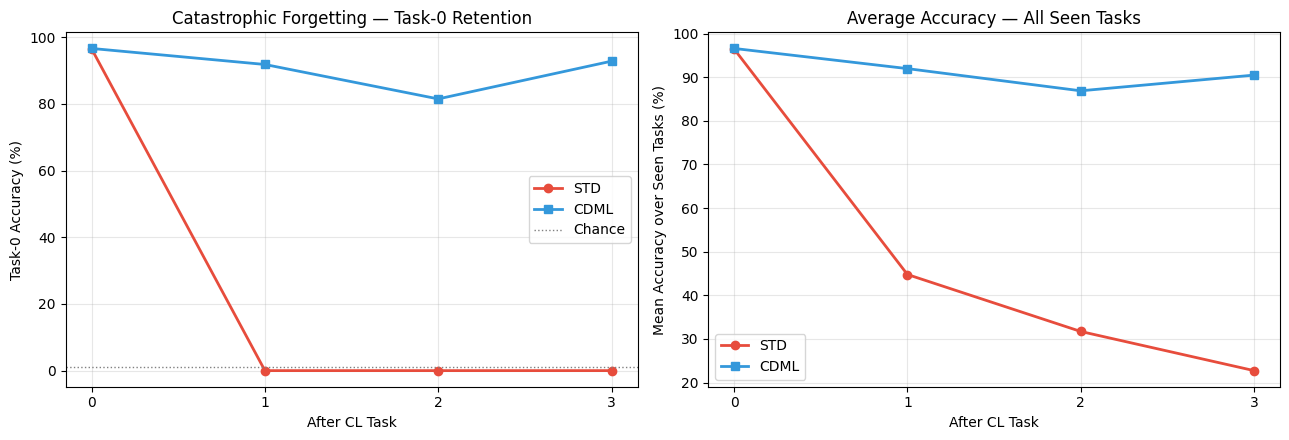

Saved: results/whuGAIT/08a_cl_forgetting.png


In [7]:
task_nums = list(range(N_TASKS))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Task-0 accuracy over time
ax = axes[0]
for label, color, marker in [('std', '#e74c3c', 'o'), ('cdml', '#3498db', 's')]:
    acc0 = [cl_records[label]['per_task_acc'][i][0] * 100 for i in task_nums]
    ax.plot(task_nums, acc0, f'{marker}-', color=color, linewidth=2, label=label.upper())
ax.axhline(100 / N_CLASSES, color='grey', linestyle=':', linewidth=1, label='Chance')
ax.set_xlabel('After CL Task')
ax.set_ylabel('Task-0 Accuracy (%)')
ax.set_title('Catastrophic Forgetting — Task-0 Retention')
ax.set_xticks(task_nums)
ax.legend()
ax.grid(True, alpha=0.3)

# Mean accuracy over all seen tasks
ax = axes[1]
for label, color, marker in [('std', '#e74c3c', 'o'), ('cdml', '#3498db', 's')]:
    mean_acc = [
        np.mean(list(cl_records[label]['per_task_acc'][i].values())) * 100
        for i in task_nums
    ]
    ax.plot(task_nums, mean_acc, f'{marker}-', color=color, linewidth=2, label=label.upper())
ax.set_xlabel('After CL Task')
ax.set_ylabel('Mean Accuracy over Seen Tasks (%)')
ax.set_title('Average Accuracy — All Seen Tasks')
ax.set_xticks(task_nums)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / '08a_cl_forgetting.png', dpi=150)
plt.show()
print('Saved: results/whuGAIT/08a_cl_forgetting.png')

## 5. Summary

The CDML model retains task-0 accuracy throughout training while the standard model drops to chance immediately after task 1. The CL-trained backbones are saved to `checkpoints/whuGAIT/cl8/` and loaded by NB08b for authenticator training.

| Method | T0 acc after T3 | Mean acc after T3 |
|---|---|---|
| Std | ~0% | ~23% |
| CDML | ~93% | ~90% |